# Polynomial Regression 

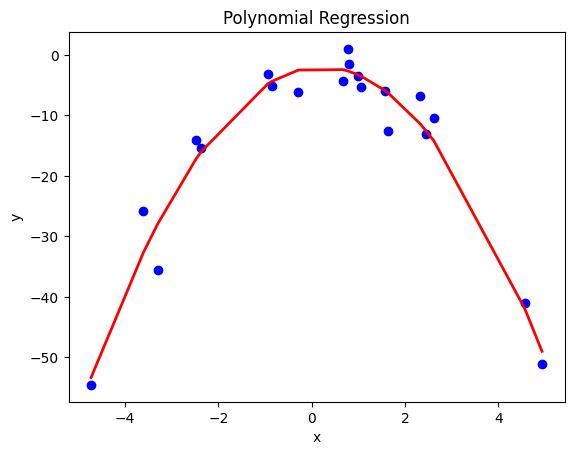

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Step 1: Create the dummy data 
np.random.seed(0)  # For reproducibility
x = 2 - 3 * np.random.normal(0, 1, 20)
y = x - 2 * (x ** 2) + np.random.normal(-3, 3, 20)

# Reshaping for the model 
x = x[:, np.newaxis]
y = y[:, np.newaxis]
# Step 2: Polynomial transformation
poly_features = PolynomialFeatures(degree=2)
x_poly = poly_features.fit_transform(x)

# Step 3: Fit the linear regression model
model = LinearRegression()
model.fit(x_poly, y)
y_poly_pred = model.predict(x_poly)

# Step 4: Plot the results
import operator

plt.scatter(x, y, color='blue')
sorted_axis = operator.itemgetter(0)
sorted_zip = sorted(zip(x, y_poly_pred), key=sorted_axis)
x, y_poly_pred = zip(*sorted_zip)
plt.plot(x, y_poly_pred, color='red', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Polynomial Regression')
plt.show()

# Titanic Dataset 

In [4]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

# Data Loading

In [13]:
# Load and explore the dataset
titanic = sns.load_dataset('titanic')

# Display dataset structure
print("Dataset Columns:", titanic.columns.tolist())
print("\nMissing Values:")
print(titanic.isnull().sum())

Dataset Columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Missing Values:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


# Preprocessing 

In [15]:
# rename columns age,fare  to Age , Fare using pandas 
titanic.rename(columns={'age': 'Age', 'fare': 'Fare','pclass':'Pclass'}, inplace=True)

In [16]:
# Data Preprocessing
# Select relevant features and target (Age)
data = titanic[['Age', 'Fare', 'Pclass']].copy()

In [18]:
data.head() # Display the first few rows of the new dataset

,Age,Fare,Pclass
0,22.0,7.2500,3
1,38.0,71.2833,1
2,26.0,7.9250,3
3,35.0,53.1000,1
4,35.0,8.0500,3


# Imputation 

In [ ]:
# Handle missing values using SimpleImputer Model of sklearn
imputer = SimpleImputer(strategy='median')
data[['Age', 'Fare']] = imputer.fit_transform(data[['Age', 'Fare']])

# Model Training 

In [23]:
# Create feature matrix (X) and target vector (y)
X = data[['Fare', 'Pclass']]  # Features
y = data['Age']                # Target (Age we want to predict)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Polynomial Feature Transformation
degree = 2  # Degree of polynomial (quadratic)
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Show transformed feature names
feature_names = poly.get_feature_names_out(['Fare', 'Pclass'])
print(f"Transformed Feature Names: {feature_names}")
# Model Training
model = LinearRegression( fit_intercept=True)
model.fit(X_train_poly, y_train)

Transformed Feature Names: ['Fare' 'Pclass' 'Fare^2' 'Fare Pclass' 'Pclass^2']


LinearRegression()

# Prediction/Evaluation 

In [25]:
# Model Evaluation
y_pred = model.predict(X_test_poly)

# Calculate performance metrics
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print(f" RMSE: {test_rmse:.2f}")
print(f"R-squared: {r2:.4f}")

# Interpretation of Results
print("\nKey Insights:")
print("1. RMSE measures prediction error in years (lower is better)")
print("2. R-squared shows how well features explain age variation")
print("3. Comparing train/test RMSE helps detect overfitting")




Model Performance:
 RMSE: 11.94
R-squared: 0.1631

Key Insights:
1. RMSE measures prediction error in years (lower is better)
2. R-squared shows how well features explain age variation
3. Comparing train/test RMSE helps detect overfitting


# Visualization 

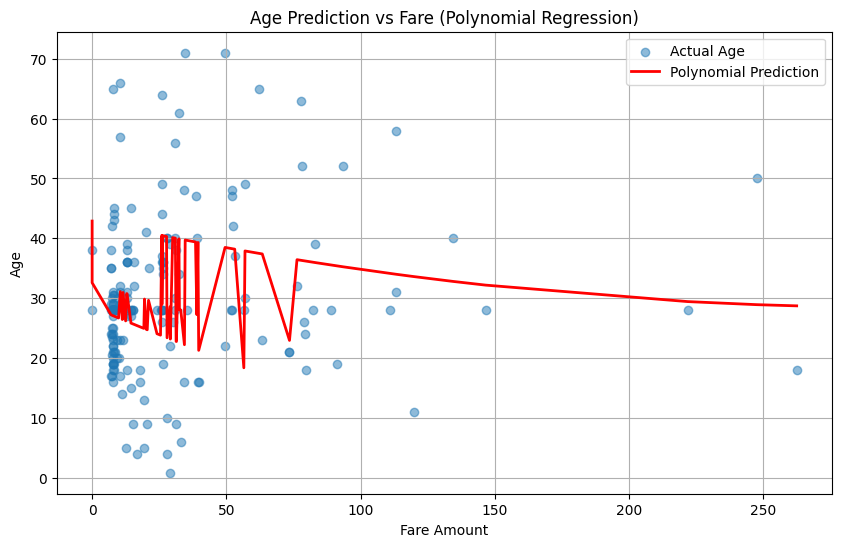

In [26]:
# Visualize Results (1D view using Fare only)
plt.figure(figsize=(10, 6))

# Sort values for smooth curve
sort_idx = X_test['Fare'].argsort()
X_sorted = X_test['Fare'].iloc[sort_idx]
y_sorted = y_test.iloc[sort_idx]
pred_sorted = y_pred[sort_idx]

plt.scatter(X_sorted, y_sorted, alpha=0.5, label='Actual Age')
plt.plot(X_sorted, pred_sorted, 'r-', linewidth=2, label='Polynomial Prediction')
plt.title('Age Prediction vs Fare (Polynomial Regression)')
plt.xlabel('Fare Amount')
plt.ylabel('Age')
plt.legend()
plt.grid(True)
plt.show()

# Use Fare to Predict Age

Coefficients: [ 0.          0.07954644 -0.00018754]
Intercept: 27.917452318597284
R-squared: -0.03


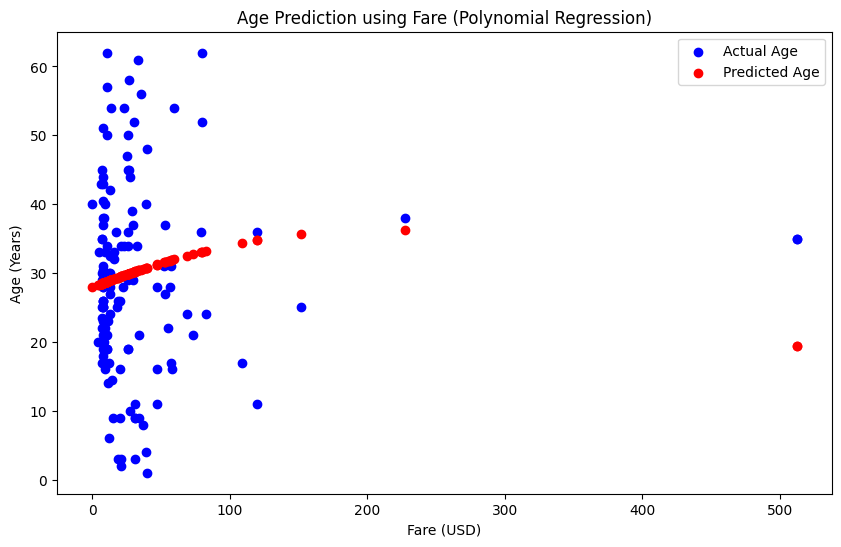

In [30]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Load and prepare Titanic dataset
titanic = sns.load_dataset('titanic')
# Rename columns for consistency
titanic.rename(columns={'age': 'Age', 'fare': 'Fare'}, inplace=True)
# Select relevant columns and clean data
data = titanic[['Age', 'Fare']].dropna()  # Remove missing values for simplicity
X = data['Fare'].values.reshape(-1, 1)    # Feature: Fare (converted to 2D array)
y = data['Age'].values                    # Target: Age

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create polynomial features (degree=2 creates X and X^2 terms)
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Create and train polynomial regression model
model = LinearRegression()
model.fit(X_train_poly, y_train)

# Make predictions and evaluate
y_pred = model.predict(X_test_poly)
r2 = r2_score(y_test, y_pred)

# Print model coefficients and performance
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")
print(f"R-squared: {r2:.2f}")

# Visualize results
plt.figure(figsize=(10,6))
plt.scatter(X_test, y_test, color='blue', label='Actual Age')
plt.scatter(X_test, y_pred, color='red', label='Predicted Age')
plt.title('Age Prediction using Fare (Polynomial Regression)')
plt.xlabel('Fare (USD)')
plt.ylabel('Age (Years)')
plt.legend()
plt.show()
